In [1]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
sys.path.append('/Users/mariana/Documents/projects/Huawei/tdsurv/lib')


from tdsurv import CoxPH
from tdsurv import concordance_index as tdsurv_ci
from deep_lambda_cox import DeepLambdaSA

from utils import concordance_index, unroll_time, unroll, score
import yaml
import jax
import jax.numpy as jnp
import haiku as hk
import numpy as np
import matplotlib.pyplot as plt

# PCB2 Dataset

In [25]:
config_path = '../configs/config_pbc.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [26]:
config['axis'] = 1

In [27]:
task = config['dataset_name']
task

'pbc2'

In [28]:
agent = DeepLambdaSA(config, 42)

In [29]:
seqs = agent.data['seqs'].astype(np.float32)
ts = agent.data['ts']
cs = agent.data['cs']

n, H, _ = seqs.shape

d = seqs.shape[2]
n_feats = d - 1
# xs = jnp.concatenate((xs, jnp.tile(jnp.eye(H), (n, 1, 1))), axis=-1)
# agent.integrated_brier_score(xs[:,0], ts, cs)

In [30]:
test_size = 0.2
size = int(n * (1-test_size))
size

249

In [31]:
seqs.shape

(312, 16, 15)

In [32]:
# 5-fold cross-validation
rng = np.random.default_rng(seed=0)
n_folds = 5
zs = np.append(((n / n_folds) * np.arange(n_folds)).astype(int), n)
idx = rng.permutation(n)
idx = jnp.array(idx)

def get_fold(fold):
    z1 = zs[fold]
    z2 = zs[fold + 1]
    idx_train = jnp.concatenate((idx[:z1], idx[z2:]))
    idx_valid = idx[z1:z2]
    return (
        (seqs[idx_train], ts[idx_train], cs[idx_train]),
        (seqs[idx_valid], ts[idx_valid], cs[idx_valid]),
        (idx_train, idx_valid)
    )

In [33]:
%%time

sizes = [10, 30, 50, 100]  # Test size is 20% of dataset 

ci_is = np.zeros((n_folds, len(sizes)))
ci_lm = np.zeros((n_folds, len(sizes)))
ci_td = np.zeros((n_folds, len(sizes)))
ci_dtd = np.zeros((n_folds, len(sizes)))

ibs_is = np.zeros((n_folds, len(sizes)))
ibs_lm = np.zeros((n_folds, len(sizes)))
ibs_td = np.zeros((n_folds, len(sizes)))
ibs_dtd = np.zeros((n_folds, len(sizes)))

l2 = 0.0

for fold in range(n_folds):
    (seqs_t, ts_t, cs_t), (seqs_v, ts_v, cs_v), (i_tr, i_val) = get_fold(fold)
    for i, size in enumerate(sizes):
        print(".", end="")
        seqs_, ts_, cs_ = unroll(seqs_t[:size], ts_t[:size], cs_t[:size])

        config['axis'] = 1

        model = CoxPH(horizon=H, n_feats=d)
        
        # Initial state.
        model.params = np.zeros_like(model.params)
        model.fit(seqs_t[:size], ts_t[:size], cs_t[:size], lambda_=1.0, l2=l2)
        ci_is[fold, i] = tdsurv_ci(model.score(seqs_v[:, 0]), ts_v, cs_v)
        ibs_is[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        
        # Landmarking.
        model.params = np.zeros_like(model.params)
        model.fit(seqs_, ts_, cs_, lambda_=1.0, l2=l2)
        ci_lm[fold, i] = tdsurv_ci(model.score(seqs_v[:, 0]), ts_v, cs_v)
        ibs_lm[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        
        # Temporal difference.
        model.params = np.zeros_like(model.params)
        model.fit(seqs_, ts_, cs_, lambda_=0.0, n_iters=100, l2=l2)
        ci_td[fold, i] = tdsurv_ci(model.score(seqs_v[:, 0]), ts_v, cs_v)
        ibs_td[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)

        # Deep TD
        config['axis'] = 2
        model = DeepLambdaSA(config, seed=42)
        model.lambda_ = 0.0

        seq_tr = model.data['seqs'][i_tr][:size]
        seq_val = model.data['seqs'][i_val]
        ts_tr = model.data['ts'][i_tr][:size]
        ts_val = model.data['ts'][i_val]
        cs_tr = model.data['cs'][i_tr][:size]
        cs_val = model.data['cs'][i_val]
        ys_tr = model.data['target'][i_tr][:size]
        ys_val = model.data['target'][i_val]
        m_tr = model.data['mask'][i_tr][:size]
        m_val = model.data['mask'][i_val]
        h_tr = model.data['h_ws'][i_tr][:size]
        h_val = model.data['h_ws'][i_val]

        assert np.all(seq_tr == seqs_t[:size])
        assert np.all(seq_val == seqs_v)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        train_gen.X = seq_tr
        train_gen.ts = ts_tr
        train_gen.cs = cs_tr
        train_gen.y = ys_tr
        train_gen.mask = m_tr
        train_gen.h_ws = h_tr

        _ = model.train(train_gen)
        surv = model.survival_curve(seq_val)
        scores = model.scores(seq_val, q=0.0)
        ci_dtd[fold, i] = concordance_index(scores, ts_val, cs_val)
        ibs_dtd[fold, i] = model.integrated_brier_score(surv[:,0], ts_val, cs_val)
        
    print()

....
....
....
....
....
CPU times: user 45.4 s, sys: 3.02 s, total: 48.4 s
Wall time: 37.3 s


# Aids dataset

In [34]:
config_path = '../configs/config_aids.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [35]:
config['axis'] = 1

In [36]:
task = config['dataset_name']
task

'aids'

In [37]:
agent = DeepLambdaSA(config, 42)

In [38]:
seqs = agent.data['seqs'].astype(np.float32)
ts = agent.data['ts']
cs = agent.data['cs']

n, H, _ = seqs.shape

d = seqs.shape[2]
n_feats = d - 1
# xs = jnp.concatenate((xs, jnp.tile(jnp.eye(H), (n, 1, 1))), axis=-1)
# agent.integrated_brier_score(xs[:,0], ts, cs)

In [39]:
test_size = 0.2
size = int(n * (1-test_size))
size

373

In [40]:
seqs.shape

(467, 5, 5)

In [41]:
d

5

In [42]:
# 5-fold cross-validation
rng = np.random.default_rng(seed=0)
n_folds = 5
zs = np.append(((n / n_folds) * np.arange(n_folds)).astype(int), n)
idx = rng.permutation(n)
idx = jnp.array(idx)

def get_fold(fold):
    z1 = zs[fold]
    z2 = zs[fold + 1]
    idx_train = jnp.concatenate((idx[:z1], idx[z2:]))
    idx_valid = idx[z1:z2]
    return (
        (seqs[idx_train], ts[idx_train], cs[idx_train]),
        (seqs[idx_valid], ts[idx_valid], cs[idx_valid]),
        (idx_train, idx_valid)
    )

In [43]:
%%time

sizes = [10, 30, 50, 100]  # Test size is 20% of dataset 

aids_ci_is = np.zeros((n_folds, len(sizes)))
aids_ci_lm = np.zeros((n_folds, len(sizes)))
aids_ci_td = np.zeros((n_folds, len(sizes)))
aids_ci_dtd = np.zeros((n_folds, len(sizes)))

aids_ibs_is = np.zeros((n_folds, len(sizes)))
aids_ibs_lm = np.zeros((n_folds, len(sizes)))
aids_ibs_td = np.zeros((n_folds, len(sizes)))
aids_ibs_dtd = np.zeros((n_folds, len(sizes)))

l2 = 0.0

for fold in range(n_folds):
    (seqs_t, ts_t, cs_t), (seqs_v, ts_v, cs_v), (i_tr, i_val) = get_fold(fold)
    for i, size in enumerate(sizes):
        print(".", end="")
        seqs_, ts_, cs_ = unroll(seqs_t[:size], ts_t[:size], cs_t[:size])

        config['axis'] = 1

        model = CoxPH(horizon=H, n_feats=d)
        
        # Initial state.
        model.params = np.zeros_like(model.params)
        model.fit(seqs_t[:size], ts_t[:size], cs_t[:size], lambda_=1.0, l2=l2)
        aids_ci_is[fold, i] = tdsurv_ci(model.score(seqs_v[:, 0]), ts_v, cs_v)
        aids_ibs_is[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        
        # Landmarking.
        model.params = np.zeros_like(model.params)
        model.fit(seqs_, ts_, cs_, lambda_=1.0, l2=l2)
        aids_ci_lm[fold, i] = tdsurv_ci(model.score(seqs_v[:, 0]), ts_v, cs_v)
        aids_ibs_lm[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        
        # Temporal difference.
        model.params = np.zeros_like(model.params)
        model.fit(seqs_, ts_, cs_, lambda_=0.0, n_iters=100, l2=l2)
        aids_ci_td[fold, i] = tdsurv_ci(model.score(seqs_v[:, 0]), ts_v, cs_v)
        aids_ibs_td[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)

        # Deep TD
        config['axis'] = 2
        model = DeepLambdaSA(config, seed=42)
        model.lambda_ = 0.0

        seq_tr = model.data['seqs'][i_tr][:size]
        seq_val = model.data['seqs'][i_val]
        ts_tr = model.data['ts'][i_tr][:size]
        ts_val = model.data['ts'][i_val]
        cs_tr = model.data['cs'][i_tr][:size]
        cs_val = model.data['cs'][i_val]
        ys_tr = model.data['target'][i_tr][:size]
        ys_val = model.data['target'][i_val]
        m_tr = model.data['mask'][i_tr][:size]
        m_val = model.data['mask'][i_val]
        h_tr = model.data['h_ws'][i_tr][:size]
        h_val = model.data['h_ws'][i_val]

        assert np.all(seq_tr == seqs_t[:size])
        assert np.all(seq_val == seqs_v)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        train_gen.X = seq_tr
        train_gen.ts = ts_tr
        train_gen.cs = cs_tr
        train_gen.y = ys_tr
        train_gen.mask = m_tr
        train_gen.h_ws = h_tr

        _ = model.train(train_gen)
        surv = model.survival_curve(seq_val)
        scores = model.scores(seq_val, q=0.0)
        aids_ci_dtd[fold, i] = concordance_index(scores, ts_val, cs_val)
        aids_ibs_dtd[fold, i] = model.integrated_brier_score(surv[:,0], ts_val, cs_val)
        
    print()

....
....
....
....
....
CPU times: user 21.8 s, sys: 719 ms, total: 22.5 s
Wall time: 24.1 s


# Random Walk 

In [52]:
from scipy.special import expit as sigmoid
from utils import get_targets_and_masks

In [62]:
# Borrowed from tdsurv (https://github.com/spotify-research/tdsurv/blob/main/notebooks/random-walk-final.ipynb)
def make_generator(mat, sigma, sigma0, thetas, bias, rng):
    """Sample from a Gauss-Markov process.
    
    Initial state:
    
        x_0 = noise(sigma0)
    
    Transition dynamics:
    
        x_nxt = np.dot(mat, x) + noise(sigma)
        
    Churn probability:
    
        p = sigmoid(np.dot(x, thetas) + bias)
    """
    n_dims = mat.shape[0]
    def gen(n_samples, horizon):
        seqs = np.zeros((n_samples, horizon + 1, n_dims + 1))
        ts = np.zeros(n_samples, dtype=int)
        cs = np.zeros(n_samples, dtype=bool)
        for i in range(n_samples):
            seqs[i, 0] = np.append(sigma0 * rng.normal(size=n_dims), 1)
            ts[i] = 1
            for j in range(0, horizon):
                p = sigmoid(np.dot(seqs[i, j, :-1], thetas) + bias)
                if rng.uniform() < p:
                    break
                ts[i] += 1
                seqs[i, j + 1] = np.append(
                    np.dot(mat, seqs[i, j + 1, :-1]) + sigma * rng.normal(size=n_dims),
                    1,
                )
            if ts[i] > horizon:
                ts[i] = horizon
                cs[i] = True
        tgt_lm, hws_lm, mask_lm = get_targets_and_masks(seqs, ts, cs, landmark=True)
        return (seqs.astype(np.float32), ts, cs, tgt_lm, hws_lm, mask_lm)
    return gen

In [75]:
rng = np.random.default_rng(seed=0)
n_dims = 20
horizon = 10
d = n_dims + 1

# Churn parameters.
thetas = rng.normal(size=n_dims)
bias = -3

# Transition dynamics.
mat = 1.0 * np.eye(n_dims)
sigma = 0.5
sigma0 = 1.0 # Affect results quite a lot

gen = make_generator(mat, sigma, sigma0, thetas, bias, rng)
seqs_v, ts_v, cs_v, y_v, hws_v, m_v = gen(n_samples=10000, horizon=horizon)

In [76]:
seqs_v.dtype

dtype('float32')

In [77]:
H = horizon + 1

In [78]:
d

21

In [79]:
seqs_v.shape

(10000, 11, 21)

In [80]:
# N-fold cross-validation
n_folds = 5
data = list()
for i in range(n_folds):
    data.append(gen(n_samples=300, horizon=horizon))

In [81]:
# "dummy" config file
config_path = '../configs/config_rw.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [82]:
%%time

sizes = [10, 30, 50, 100]  # Test size is 20% of dataset 

rw_ci_is = np.zeros((n_folds, len(sizes)))
rw_ci_lm = np.zeros((n_folds, len(sizes)))
rw_ci_td = np.zeros((n_folds, len(sizes)))
rw_ci_dtd = np.zeros((n_folds, len(sizes)))

rw_ibs_is = np.zeros((n_folds, len(sizes)))
rw_ibs_lm = np.zeros((n_folds, len(sizes)))
rw_ibs_td = np.zeros((n_folds, len(sizes)))
rw_ibs_dtd = np.zeros((n_folds, len(sizes)))

l2 = 1e-4

for fold in range(n_folds):
    seqs_t, ts_t, cs_t, y_t, hws_t, m_t = data[fold]
    for i, size in enumerate(sizes):
        print(".", end="")
        seqs_, ts_, cs_ = unroll(seqs_t[:size], ts_t[:size], cs_t[:size])

        config['axis'] = 1

        model = CoxPH(horizon=H, n_feats=d)
        
        # Initial state.
        model.params = np.zeros_like(model.params)
        model.fit(seqs_t[:size], ts_t[:size], cs_t[:size], lambda_=1.0, l2=l2)
        rw_ci_is[fold, i] = tdsurv_ci(model.score(seqs_v[:, 0]), ts_v, cs_v)
        rw_ibs_is[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        
        # Landmarking.
        model.params = np.zeros_like(model.params)
        model.fit(seqs_, ts_, cs_, lambda_=1.0, l2=l2)
        rw_ci_lm[fold, i] = tdsurv_ci(model.score(seqs_v[:, 0]), ts_v, cs_v)
        rw_ibs_lm[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        
        # Temporal difference.
        model.params = np.zeros_like(model.params)
        model.fit(seqs_, ts_, cs_, lambda_=0.0, n_iters=100, l2=l2)
        rw_ci_td[fold, i] = tdsurv_ci(model.score(seqs_v[:, 0]), ts_v, cs_v)
        rw_ibs_td[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)

        # Deep TD
        config['axis'] = 2
        config['weight_decay'] = 1e-4
        config['dataset_kwargs']['horizon'] = H
        model = DeepLambdaSA(config, seed=42)
        model.lambda_ = 0.0

        train_gen, test_gen = model.get_train_test(test_size=size)
        train_gen.X = seqs_t[:size]
        train_gen.ts = ts_t[:size]
        train_gen.cs = cs_t[:size]
        train_gen.y = y_t[:size]
        train_gen.mask = m_t[:size]
        train_gen.h_ws = hws_t[:size]

        _ = model.train(train_gen)
        surv = model.survival_curve(seqs_v)
        scores = model.scores(seqs_v, q=0.0)
        rw_ci_dtd[fold, i] = concordance_index(scores, ts_v, cs_v)
        rw_ibs_dtd[fold, i] = model.integrated_brier_score(surv[:,0], ts_v, cs_v)
        
    print()

....
....
....
....
....
CPU times: user 28 s, sys: 1.2 s, total: 29.2 s
Wall time: 25.7 s


# Compile results and plot

In [83]:
all_res = [
    [(0, ci_is, 'SA Init State'), 
     (1, ci_lm, 'SA Landmarking'),
     (2, ci_td, 'TCSA'),
     (3, ci_dtd, 'DeepTCSA')],
    [(0, aids_ci_is, 'SA Init State'), 
     (1, aids_ci_lm, 'SA Landmarking'),
     (2, aids_ci_td, 'TCSA'),
     (3, aids_ci_dtd, 'DeepTCSA')],
    [(0, rw_ci_is, 'SA Init State'), 
     (1, rw_ci_lm, 'SA Landmarking'),
     (2, rw_ci_td, 'TCSA'),
     (3, rw_ci_dtd, 'DeepTCSA')],
    [(0, ibs_is, 'SA Init State'), 
     (1, ibs_lm, 'SA Landmarking'),
     (2, ibs_td, 'TCSA'),
     (3, ibs_dtd, 'DeepTCSA')],
    [(0, aids_ibs_is, 'SA Init State'), 
     (1, aids_ibs_lm, 'SA Landmarking'),
     (2, aids_ibs_td, 'TCSA'),
     (3, aids_ibs_dtd, 'DeepTCSA')],
    [(0, rw_ibs_is, 'SA Init State'), 
     (1, rw_ibs_lm, 'SA Landmarking'),
     (2, rw_ibs_td, 'TCSA'),
     (3, rw_ibs_dtd, 'DeepTCSA')]
]

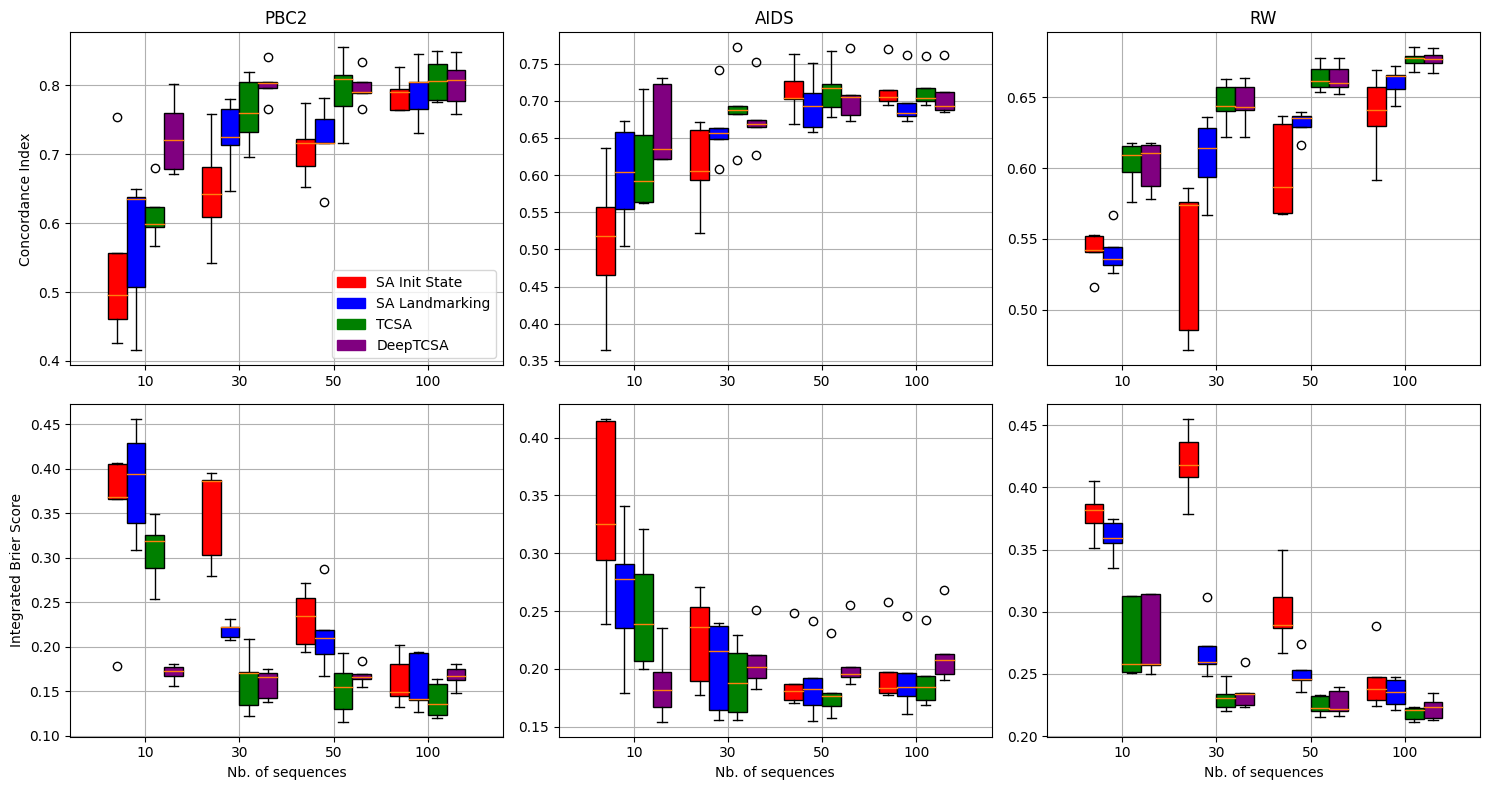

In [85]:

# Define colors for each key
colors = {'SA Init State': 'red', 'SA Landmarking': 'blue', 'TCSA': 'green', 'DeepTCSA': 'purple'}

# Prepare data for plotting
tasks = sizes
keys = colors.keys()


# Create a 2x3 grid for the plots
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

# Flatten the axs array to make it easier to iterate
axs = axs.flatten()

positions = np.arange(len(sizes))

# Loop through the subplots and plot your custom content
for i, ax in enumerate(axs):

    res = all_res[i]
    
    # Create boxplots
    for j, data, key in res:

        box = ax.boxplot(data, positions=positions + j * 0.2,
                         widths=0.2, patch_artist=True, boxprops=dict(facecolor=colors[key]))
    
    # Create legend
    if i == 0:
        legend_labels = [plt.Rectangle((0, 0), 1, 1, color=colors[key]) for key in keys]
        ax.legend(legend_labels, keys, loc='lower right')
    
    # Set labels and title
    ax.set_xticks(np.arange(len(tasks)) + 0.2 * (len(keys) - 1) / 2)
    ax.set_xticklabels(tasks)
    ax.grid()
    
    if i == 0:
        ax.set_ylabel('Concordance Index')
        ax.set_title(f'PBC2')
    if i == 1:
        ax.set_title(f'AIDS')
    if i == 2:
        ax.set_title(f'RW')
    if i == 3:
        ax.set_ylabel('Integrated Brier Score')
    if i > 2:
        ax.set_xlabel('Nb. of sequences')

# Adjust layout for better spacing
save_fig = True
if save_fig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/smallDS_results.pdf".format(task), format="pdf")
    
# Show the plot
plt.show()

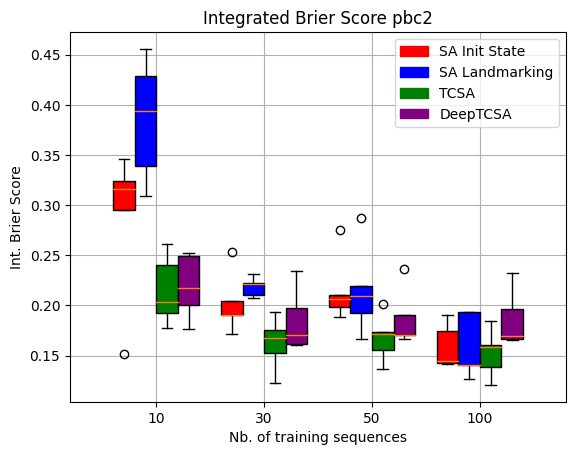

In [65]:
save_fig = False

# Define colors for each key
colors = {'SA Init State': 'red', 'SA Landmarking': 'blue', 'TCSA': 'green', 'DeepTCSA': 'purple'}

# Prepare data for plotting
tasks = sizes
keys = colors.keys()

fig, ax = plt.subplots()
positions = np.arange(len(sizes))

# Create boxplots
for i, d, key in [(0, ibs_is, 'SA Init State'), 
                  (1, ibs_lm, 'SA Landmarking'),
                  (2, ibs_td, 'TCSA'),
                  (3, ci_dtd, 'DeepTCSA')]:
    data = d
    box = ax.boxplot(data, positions=positions + i * 0.2,
                     widths=0.2, patch_artist=True, boxprops=dict(facecolor=colors[key]))

# Create legend
legend_labels = [plt.Rectangle((0, 0), 1, 1, color=colors[key]) for key in keys]
ax.legend(legend_labels, keys, loc='upper right')

# Set labels and title
ax.set_xticks(np.arange(len(tasks)) + 0.2 * (len(keys) - 1) / 2)
ax.set_xticklabels(tasks)
ax.set_xlabel('Nb. of training sequences')
ax.set_ylabel('Int. Brier Score')
ax.set_title('Integrated Brier Score {}'.format(task))
ax.grid()

if save_fig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/{}/Int_brier_score.pdf".format(task), format="pdf")

plt.show()

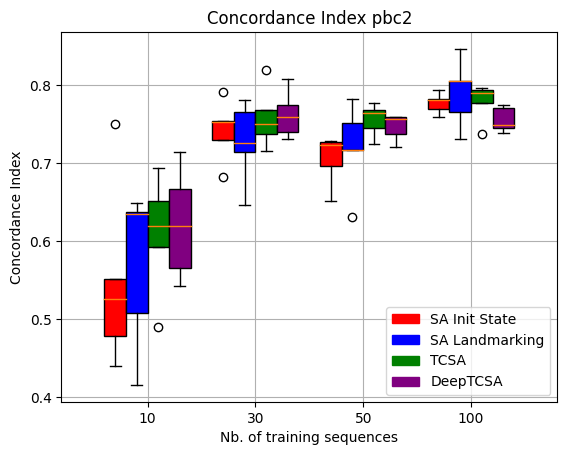

In [66]:

# Define colors for each key
colors = {'SA Init State': 'red', 'SA Landmarking': 'blue', 'TCSA': 'green', 'DeepTCSA': 'purple'}

# Prepare data for plotting
tasks = sizes
keys = colors.keys()

fig, ax = plt.subplots()
positions = np.arange(len(sizes))

# Create boxplots
for i, d, key in [(0, ci_is, 'SA Init State'), 
                  (1, ci_lm, 'SA Landmarking'),
                  (2, ci_td, 'TCSA'),
                  (3, ci_dtd, 'DeepTCSA')]:
    data = d
    box = ax.boxplot(data, positions=positions + i * 0.2,
                     widths=0.2, patch_artist=True, boxprops=dict(facecolor=colors[key]))

# Create legend
legend_labels = [plt.Rectangle((0, 0), 1, 1, color=colors[key]) for key in keys]
ax.legend(legend_labels, keys, loc='lower right')

# Set labels and title
ax.set_xticks(np.arange(len(tasks)) + 0.2 * (len(keys) - 1) / 2)
ax.set_xticklabels(tasks)
ax.set_xlabel('Nb. of training sequences')
ax.set_ylabel('Concordance Index')
ax.set_title('Concordance Index {}'.format(task))
ax.grid()

if save_fig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/{}/Concordance_idx.pdf".format(task), format="pdf")

plt.show()